# **Introduction to Linear Regression**




## **Part 1: Motivation & Historical Context**

**Core Ideas**

- Linear regression emerged from astronomy and navigation problems
- Goal: improve estimates from noisy observations
- Combining multiple measurements leads to better estimates

**Historical Milestones**
- Early ideas of averaging observations (1700s-1720s)
- First published least-squares method by Adrien-Marie Legendre (1805)
- Competing claims by Carl Friedrich Gauss
- Practical takeaway: *who invented it matters less than why it works*

<br>

***Linear regression was not invented for data science—it was invented to reduce error in real measurements.***

## **Part 2: What Is a Linear Relationship?**

A linear relationship is a connection between two variables that creates a straight line when graphed.

It means that as one variable changes, the other changes at a constant, proportional rate.

**Mathematical Form:**

  $~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$ $y = mx + b$

where:

*   𝑚 is the slope (rate of change).
*   𝑏 is the y-intercept (where the line crosses the y-axis).

In [ ]:
#@title Example Perfect fit

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
# --- 3 fixed data points ---
x_data = np.array([1, 3, 5])
y_data = np.array([2, 4, 6])

def fit_line(m=1.0, b=0.0):
    x = np.linspace(0, 6, 100)
    y = m * x + b

    plt.figure(figsize=(6,4))

    # plot data points
    plt.scatter(x_data, y_data, s=80, label="Data points")

    # plot fitted line
    plt.plot(x, y, label=f"y = {m:.2f}x + {b:.2f}")

    # plot residuals
    for xi, yi in zip(x_data, y_data):
        plt.plot([xi, xi], [yi, m*xi + b], linestyle="dotted")

    plt.xlim(0, 6)
    plt.ylim(0, 8)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(
    fit_line,
    m=widgets.FloatSlider(value=1, min=0, max=3, step=0.1),
    b=widgets.FloatSlider(value=0, min=-2, max=4, step=0.1)
);



interactive(children=(FloatSlider(value=1.0, description='m', max=3.0), FloatSlider(value=0.0, description='b'…

- **Perfect fit:** points lie exactly on a line

- **Real data:** points scatter around a line

In [ ]:
#@title Example Real data
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
# --- 3 fixed data points ---
x_data = np.array([1, 3, 5])
y_data = np.array([3, 4, 4])

def fit_line(m=1.0, b=0.0):
    x = np.linspace(0, 6, 100)
    y = m * x + b

    plt.figure(figsize=(6,4))

    # plot data points
    plt.scatter(x_data, y_data, s=80, label="Data points")

    # plot fitted line
    plt.plot(x, y, label=f"y = {m:.2f}x + {b:.2f}")

    # plot residuals
    for xi, yi in zip(x_data, y_data):
        plt.plot([xi, xi], [yi, m*xi + b], linestyle="dotted")

    plt.xlim(0, 6)
    plt.ylim(0, 8)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(
    fit_line,
    m=widgets.FloatSlider(value=1, min=0, max=3, step=0.1),
    b=widgets.FloatSlider(value=0, min=-2, max=4, step=0.1)
);



interactive(children=(FloatSlider(value=1.0, description='m', max=3.0), FloatSlider(value=0.0, description='b'…

**Residual:** distance between observed value and predicted value

Residuals can be positive or negative

The “best” line is the one that **minimizes total error**, not one that passes through every point.

The goal is to find a line that best represents the relationship within the scattered data points, which can then be used to predict values for new, unseen data.

This process involves minimizing the 'residuals' or errors between the line and the actual data points.

## **Part 3: From Data to Mathematical Notation**

#### **Translating a Dataset**

| hours_studied| final_grade (%) |                
| ---------------------: | --------------: |
|                      3 |              68 |
|                      6 |              80 |
|                     10 |              94 |
|                      8 |              87 |


<br>

Recall the simplest mathematical formulation (Simple Linear Regression):
  $~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$ $y = mx + b$

<br>

| x | y |                
| ---------------------: | --------------: |
|                      3 |              68 |
|                      6 |              80 |
|                     10 |              94 |
|                      8 |              87 |

<br>

So in this case we only have one feature and need to find m and b.

Now let's consider a case that we have more than one feature:

<br>

| hours_studied | homework_avg (%) | attendance (%) | final_grade (%) |
| ---------------------: | ---------------: | -------------: | --------------: |
|                      3 |               65 |             70 |              68 |
|                      6 |               78 |             85 |              80 |
|                     10 |               92 |             95 |              94 |
|                      8 |               85 |             88 |              87 |

<br>

- **Features** → matrix **X**
- **Target** → vector **y**
- **Coefficients** → vector **β**

<br>


| $x_1$ | $x_2$ | $x_3$ | $y$ |
| ---------------------: | ---------------: | -------------: | --------------: |
|                      3 |               65 |             70 |              68 |
|                      6 |               78 |             85 |              80 |
|                     10 |               92 |             95 |              94 |
|                      8 |               85 |             88 |              87 |


<br>

- x could to $x_n$
- So we can have a subscript for the features and superscript for the actual rows.


<br>


| $x_1$ | $x_2$ | $x_3$ | $y$ |
| ---------------------: | ---------------: | -------------: | --------------: |
|   $x_1^1$ |  $x_2^1$ | $x_3^1$ |  $y_1$ |
|   $x_1^2$ |  $x_2^2$ | $x_3^2$ |  $y_2$ |
|   $x_1^3$ |  $x_2^3$ | $x_3^3$ |  $y_3$ |
|   $x_1^4$ |  $x_2^4$ | $x_3^4$ |  $y_4$ |


<br>


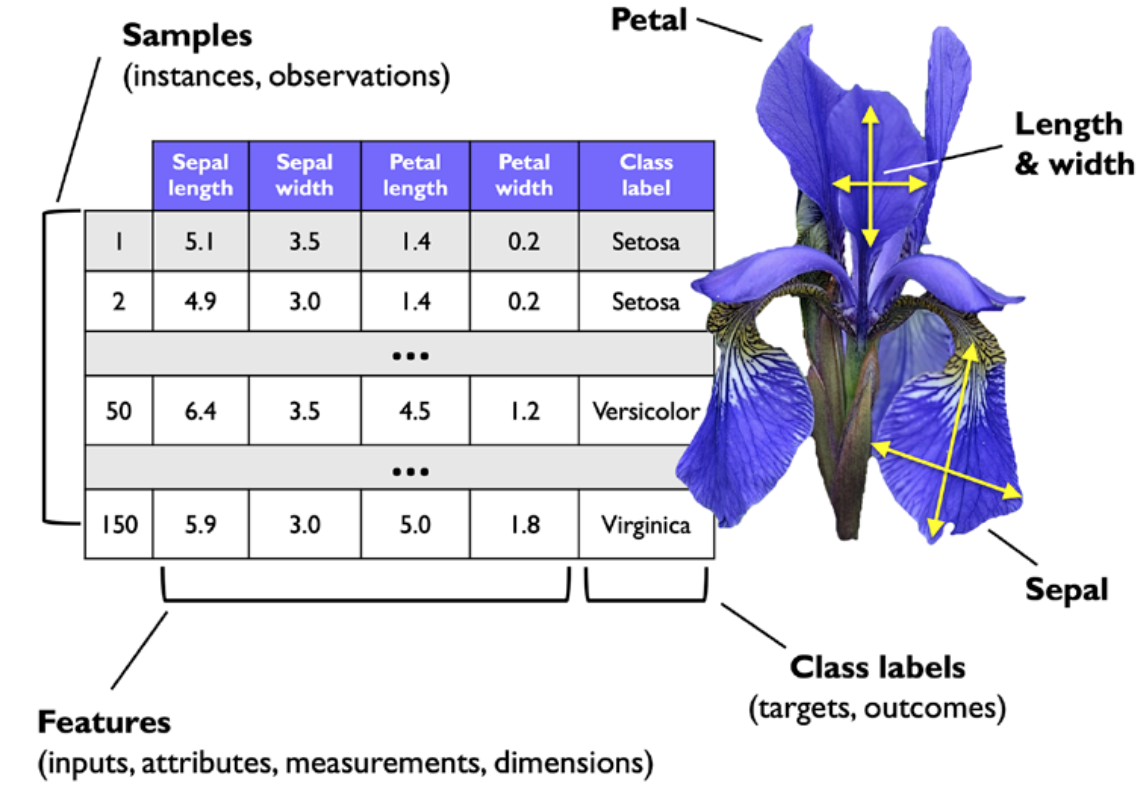

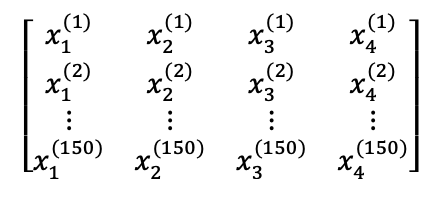

<br>

## **Part 4: Generalized Linear Regression Model**

- **Goal:** predict the value of a dependent variable that is y based off of an/some independent variable/s, x.

$$ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n $$

**or compactly:**

$$ \hat{y} = \sum_{i=1}^{n} \beta_i x_i $$

Where

- $n$ is the number of features in the dataset

**Key Distinction**

- $y$: true value  
- $\hat{y}$: predicted value (estimate: It's not possible for real data to create a set of betas that creates a perfect fit to y,)

<br>





**Key idea:**

- Describe the relationship between X & y
- Goal: Finding a linear relationship between the features X and label y.
- There is some beta coefficient for each feature to minimize the error.

<br>


## **Part 5: Solving Simple Linear Regression Using Ordinary Least Square (OLS) Method**

**Answers the question:** *How do we find the best-fit line (or hyperplane)?*

**What it is OLS:**

- OLS finds the line that minimizes the sum of squared residuals.
- An estimation method / optimization technique
- Used to find the best coefficients ($\beta_0 , \beta_1, ...$)

**Key idea:**

Chooses coefficients that minimize the sum of squared residuals

$$\sum (y - \hat{y})^2$$




**Why Square the Errors?**

- Prevents positive/negative cancellation
- Penalizes large errors more
- Makes calculus tractable (smooth derivatives)


**Can be used for:**

- Simple linear regression (1 feature)
- Multiple linear regression (many features)

 <br> <br>


#### **Case: One Feature Only**

$$ \hat{y} = \beta_0 + \beta_1 x $$



#### **OLS Closed-Form(analytical) Solutions**

**Slope:**

$$\beta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$

**Intercept:**

$$ \beta_0 = \bar{y} - \beta_1 \bar{x}$$





**Example (Students Scenario)**




| hours_studied| final_grade (%) |                
| ---------------------: | --------------: |
|                      3 |              68 |
|                      6 |              80 |
|                     10 |              94 |
|                      8 |              87 |


<br>


<br>

| x | y |                
| ---------------------: | --------------: |
|                      3 |              68 |
|                      6 |              80 |
|                     10 |              94 |
|                      8 |              87 |

<br>


**Resulting model:**

$$
\hat{y} = \beta_0 + \beta x
$$






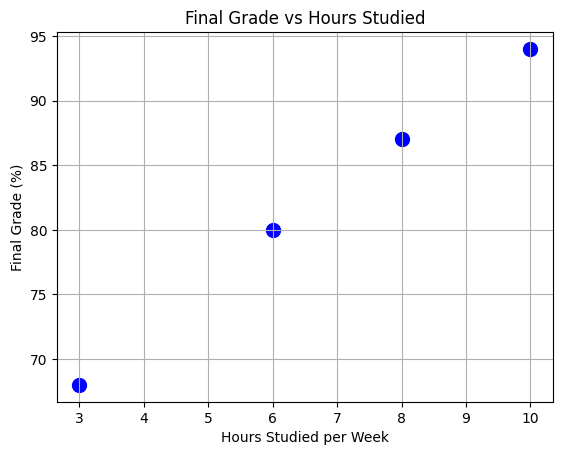

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
df = pd.DataFrame({
    "hours_studied_per_week": [3, 6, 10, 8],
    "final_grade": [68, 80, 94, 87]
})

# Scatter plot
plt.scatter(df["hours_studied_per_week"], df["final_grade"], color='blue', s=100)
plt.title("Final Grade vs Hours Studied")
plt.xlabel("Hours Studied per Week")
plt.ylabel("Final Grade (%)")
plt.grid(True)
plt.show()


| x  | y  | x - x̄ | y - ȳ  | (x-x̄)(y-ȳ) | (x-x̄)² |
| -- | -- | ------ | ------ | ----------- | ------- |
| 3  | 68 | -3.75  | -14.25 | 53.4375     | 14.0625 |
| 6  | 80 | -0.75  | -2.25  | 1.6875      | 0.5625  |
| 10 | 94 | 3.25   | 11.75  | 38.1875     | 10.5625 |
| 8  | 87 | 1.25   | 4.75   | 5.9375      | 1.5625  |


<br>

Σ(x-x̄)(y-ȳ) = 53.4375 + 1.6875 + 38.1875 + 5.9375 = 99.25

Σ(x-x̄)² = 14.0625 + 0.5625 + 10.5625 + 1.5625 = 26.75

Then slope and intercept:

- m = 99.25 / 26.75 ≈ 3.71
- b = ȳ - m x̄ = 82.25 - 3.71*6.75 ≈ 57.17


<br>

**Resulting model:**

$$
\hat{y} = 3.71 + 57.17 x
$$


<br>

- Analytical solutions (like ordinary least squares) work for a single feature.

- Expanding to multiple features makes analytical solutions quickly unscalable.

- For multiple features, we shift focus to minimizing a cost function.

- Gradient descent is the preferred method to minimize the cost function efficiently.

**NumPy Code for Step-by-Step OLS Calculation**

Write the numpy or python code for above calculation after finding coefficients plot the data along with fitted line.

In [ ]:
# DO NOT Run This Cell

x̄ = 6.75
ȳ = 82.25
x - x̄ = [-3.75 -0.75  3.25  1.25]
y - ȳ = [-14.25  -2.25  11.75   4.75]
Numerator Σ(x-x̄)(y-ȳ) = 99.25
Denominator Σ(x-x̄)^2 = 26.75
Slope (m) = 3.710280373831776
Intercept (b) = 57.205607476635514
Predicted y = [68.3364486  79.46728972 94.30841121 86.88785047]


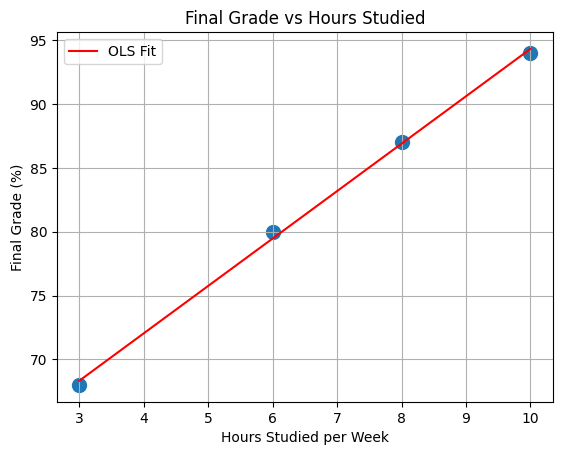

In [ ]:
# DO NOT Run This Cell